In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/ami_full.csv')

### Initial Data Inspection
Let's take a look at the first few rows, data types, and a summary of the dataset to understand its structure.

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

,meeting_id,session_id,agenda_item,window_text,time_start,time_end,drift_label
0,IS1001,IS1001b,look and usability,D: Mm ? C: of the tested people say that's it'...,1303.76,1353.76,0
1,IS1008,IS1008c,marketing expert presentation,"D: Looking for next generation of innovation ,...",998.15,1048.15,0
2,IS1001,IS1001b,marketing expert presentation,A: Oh . D: Uh . A: Uh sorry A: got a message f...,694.51,744.51,0
3,TS3012,TS3012d,interface specialist presentation,A: R_ dash C_ . B: Dash C_ ? C: I think I like...,1958.66,2008.66,1
4,TS3012,TS3012d,agenda/equipment issues,A: But we need that for the L_C_D_ display . B...,410.30,460.30,1


In [ ]:
# Display concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7040 entries, 0 to 7039
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   meeting_id   7040 non-null   object 
 1   session_id   7040 non-null   object 
 2   agenda_item  7040 non-null   object 
 3   window_text  7040 non-null   object 
 4   time_start   7040 non-null   float64
 5   time_end     7040 non-null   float64
 6   drift_label  7040 non-null   int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 385.1+ KB


In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,time_start,time_end,drift_label
count,7040.000000,7040.000000,7040.000000
mean,893.706865,943.706865,0.500000
std,619.769731,619.769731,0.500036
min,0.020000,50.020000,0.000000
25%,393.437500,443.437500,0.000000
50%,754.620000,804.620000,0.500000
75%,1304.195000,1354.195000,1.000000
max,2876.540000,2926.540000,1.000000


In [ ]:
# Count the number of unique agenda items
unique_agenda_items = df['agenda_item'].nunique()
print(f"Number of unique agenda items: {unique_agenda_items}")

Number of unique agenda items: 16


In [ ]:
# Display the top 10 most frequent agenda items
display(df['agenda_item'].value_counts())

,count
agenda_item,
evaluation of prototype(s),1024
industrial designer presentation,722
drawing exercise,704
interface specialist presentation,686
evaluation of project process,650
marketing expert presentation,634
costing,580
presentation of prototype(s),560
agenda/equipment issues,556


### Token Analysis of `window_text`
Let's analyze the `window_text` column by counting the average number of tokens (words) to understand the typical length of these text segments.

In [ ]:
# Calculate the number of tokens (words) for each entry in 'window_text'
# Assuming tokens are words separated by spaces
df['num_tokens'] = df['window_text'].apply(lambda x: len(str(x).split()))

# Calculate the average number of tokens
average_tokens = df['num_tokens'].mean()

print(f"Average number of tokens in 'window_text': {average_tokens:.2f}")

# Optionally, display descriptive statistics for token counts
display(df['num_tokens'].describe())

Average number of tokens in 'window_text': 143.80


,num_tokens
count,7040.000000
mean,143.801278
std,62.252755
min,30.000000
25%,98.000000
50%,144.000000
75%,187.000000
max,368.000000


### Distribution of `window_text` Token Counts
To further understand the length of the text segments, let's visualize the distribution of the `num_tokens` column using a histogram.

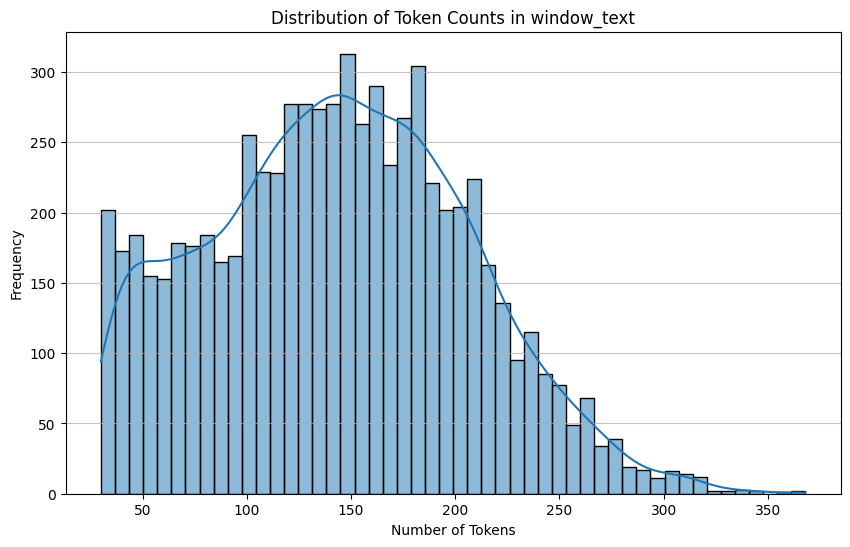

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['num_tokens'], bins=50, kde=True)
plt.title('Distribution of Token Counts in window_text')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Drift Mean per Agenda Item
Now, let's analyze the average 'drift_label' for each unique 'agenda_item'. This can help us identify which agenda items are associated with higher or lower 'drift' scores.

In [ ]:
# Calculate the mean 'drift_label' for each 'agenda_item'
drift_mean_per_agenda = df.groupby('agenda_item')['drift_label'].mean().sort_values(ascending=False)

# Display the results
display(drift_mean_per_agenda)

,drift_label
agenda_item,
agenda/equipment issues,0.5
"components, materials and energy sources",0.5
costing,0.5
drawing exercise,0.5
evaluation of project process,0.5
evaluation of prototype(s),0.5
existing products,0.5
industrial designer presentation,0.5
interface specialist presentation,0.5
